Name: Ananta Gurung
ID: 2414247

# Introduction to Python Imaging Library(PIL)

**Exercise - 1**

In [6]:
# Import libraries
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

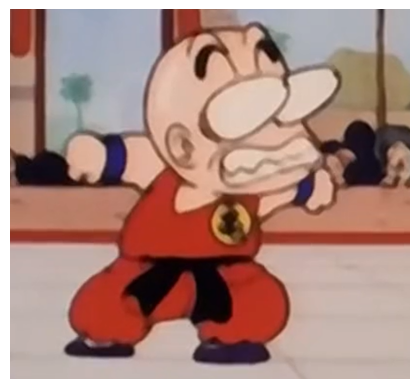

In [5]:
# 1. Read and display the image.

# Open the image
img = Image.open("/content/drive/MyDrive/AI and ML/week 1/goku.png")

# Display the image using matplotlib
plt.imshow(img)
plt.axis('off')  # Hide axis
plt.show()

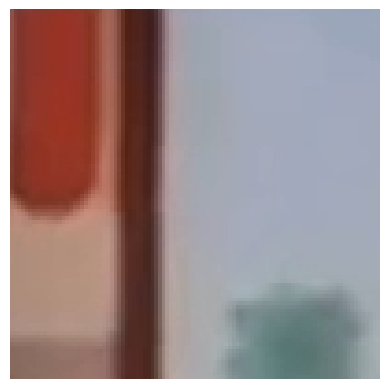

In [8]:
# 2. Display only the top left corner of 100x100 pixels.

# Convert image to NumPy array
img_array = np.array(img)

# Extract top-left 100x100 pixels using array indexing
top_left = img_array[0:100, 0:100]

# Display the extracted part
plt.imshow(top_left)
plt.axis('off')
plt.show()

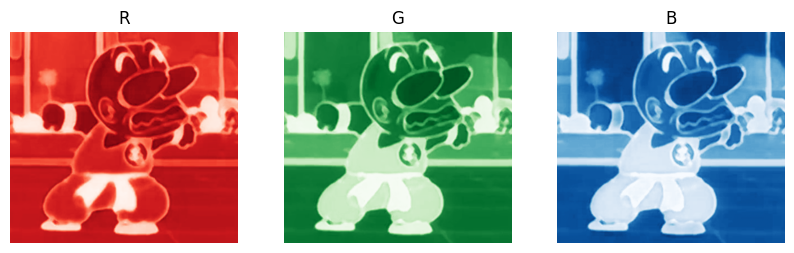

In [10]:
# 3. Show the three color channels (R, G, B).
# Separate channels using NumPy
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

# Display channels
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("R")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("G")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("B")
plt.axis("off")

plt.show()

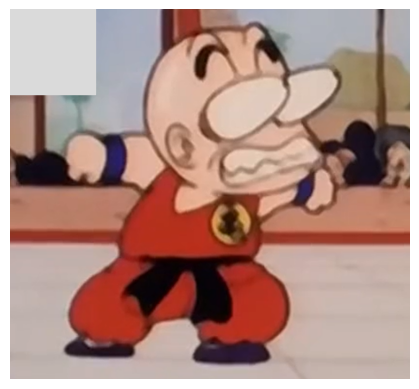

In [12]:
# 4. Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:
img_array[0:100, 0:100] = 210

# Display the modified image
plt.imshow(img_array)
plt.axis('off')
plt.show()

**Exercise - 2**

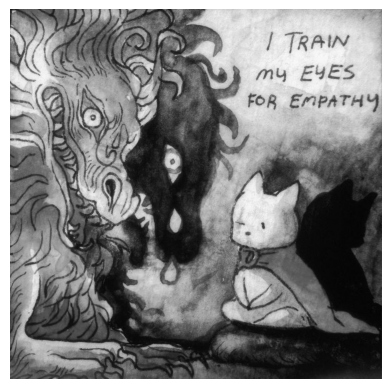

In [20]:
# 1. Load and display a grayscale image.
img = Image.open("/content/drive/MyDrive/AI and ML/week 1/empathy.jpg").convert("L")

# Display the grayscale image
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

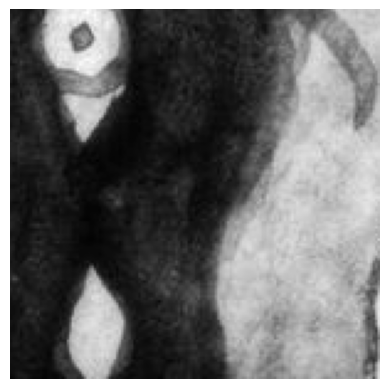

In [14]:
# 2. Extract and display the middle section of the image (150 pixels)
# Convert to NumPy array
img_array = np.array(img)

# Get image dimensions
h, w = img_array.shape

# Find center
center_h = h // 2
center_w = w // 2

# Extract 150x150 region from the center
cropped = img_array[center_h-75:center_h+75, center_w-75:center_w+75]

# Display cropped image
plt.imshow(cropped, cmap='gray')
plt.axis('off')
plt.show()

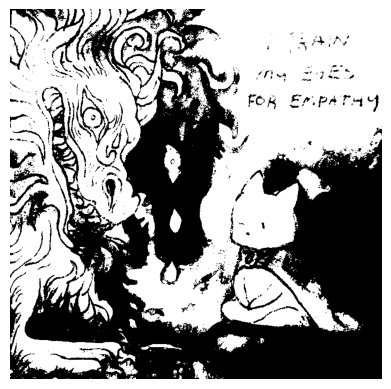

In [15]:
# 3. Apply a simple threshold to the image
# Apply threshold
binary_img = np.where(img_array < 100, 0, 255)

# Display binary image
plt.imshow(binary_img, cmap='gray')
plt.axis('off')
plt.show()

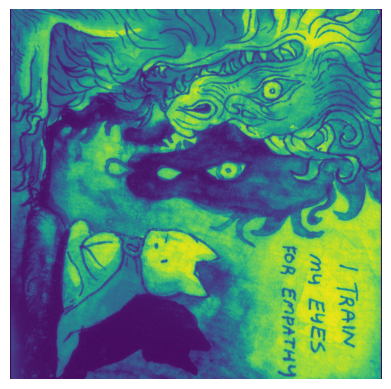

In [21]:
# 4. Rotate the image 90 degrees clockwise and display the result.
# Rotate 90 degrees clockwise
rotated_img = img.rotate(-90)

# Display the rotated image
plt.imshow(rotated_img)
plt.axis('off')
plt.show()

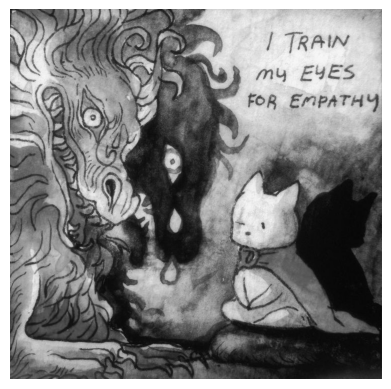

In [23]:
# 5. Convert the grayscale image to an RGB image.
# Convert to NumPy array
gray_array = np.array(img)

# Replicate grayscale values into 3 channels (RGB)
rgb_image = np.stack((gray_array, gray_array, gray_array), axis=-1)

# Display the RGB image
plt.imshow(rgb_image)
plt.axis('off')
plt.show()

**Image Compression and Decompression using PCA**

1. Load and Prepare Data:


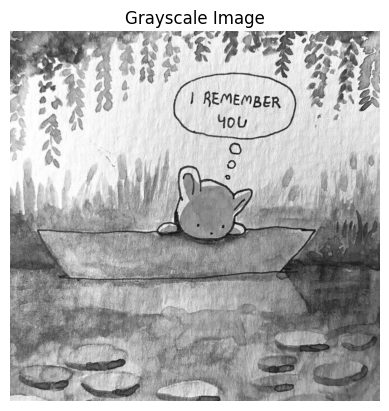

In [43]:
# Load image
img = Image.open("/content/drive/MyDrive/AI and ML/week 1/remember.jpg")   # replace with your image

# Convert to grayscale if image is color
img = img.convert("L")

# Convert to NumPy array
img_array = np.array(img)

# Display grayscale image
plt.imshow(img_array, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

In [44]:
# Center the dataset (Standardize)

# Flatten the image into a 1D dataset
data = img_array.astype(float)

# Calculate mean and standard deviation
mean = np.mean(data, axis=0)
standardized_data = data - mean  # shape: (height, width)

print("Mean after standardization:", np.mean(standardized_data))
print("Std after standardization:", np.std(standardized_data))

Mean after standardization: -1.8401579357114124e-15
Std after standardization: 52.07330033176889


In [45]:
# Covariance Matrix


# Calculate covariance matrix
cov_matrix = np.cov(standardized_data, rowvar=False)

print("Covariance Matrix:")
print(cov_matrix)

Covariance Matrix:
[[2691.87885241 2575.72799468 2524.58707483 ... 1517.96286602
  1575.30125702 1648.68592133]
 [2575.72799468 2638.72256544 2613.21947279 ... 1481.14785012
  1537.12258762 1609.55397442]
 [2524.58707483 2613.21947279 2762.60153061 ... 1456.01352041
  1515.70552721 1591.4457483 ]
 ...
 [1517.96286602 1481.14785012 1456.01352041 ... 2991.9210718
  3015.93046621 2969.15284309]
 [1575.30125702 1537.12258762 1515.70552721 ... 3015.93046621
  3173.29909605 3167.43293035]
 [1648.68592133 1609.55397442 1591.4457483  ... 2969.15284309
  3167.43293035 3283.24128217]]


2. Eigen Decomposition and Identifying Principal Components:


In [46]:
# Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigenvalues in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[sorted_indices]
eigenvectors_sorted = eigenvectors[:, sorted_indices]

print("Sorted Eigenvalues:", eigenvalues_sorted)
print("Corresponding Eigenvectors shape:", eigenvectors_sorted.shape)

Sorted Eigenvalues: [9.94434439e+05 1.60096003e+05 8.63715308e+04 5.48859505e+04
 4.93766203e+04 4.48240347e+04 3.12274564e+04 2.78556688e+04
 2.51830374e+04 2.17901101e+04 2.04781071e+04 1.93429428e+04
 1.82952053e+04 1.69445852e+04 1.61070586e+04 1.48148264e+04
 1.41001984e+04 1.30654869e+04 1.23688083e+04 1.18909043e+04
 1.07937786e+04 1.04622167e+04 1.02400801e+04 9.29005188e+03
 8.64778019e+03 8.46419086e+03 7.84802900e+03 7.56416181e+03
 7.43095879e+03 7.24127732e+03 7.01366158e+03 6.80406545e+03
 6.51448305e+03 6.31945694e+03 5.98188788e+03 5.88883212e+03
 5.69160511e+03 5.56163341e+03 5.22992331e+03 4.86082196e+03
 4.64187711e+03 4.50561198e+03 4.49134373e+03 4.35496932e+03
 4.30140588e+03 4.07106896e+03 3.88331177e+03 3.71474697e+03
 3.56622075e+03 3.39175772e+03 3.24994532e+03 3.10985502e+03
 3.05381338e+03 3.00941100e+03 2.86012101e+03 2.82963731e+03
 2.65871317e+03 2.61239908e+03 2.58032458e+03 2.47914315e+03
 2.38280857e+03 2.34258143e+03 2.24015306e+03 2.16029550e+03
 2.1

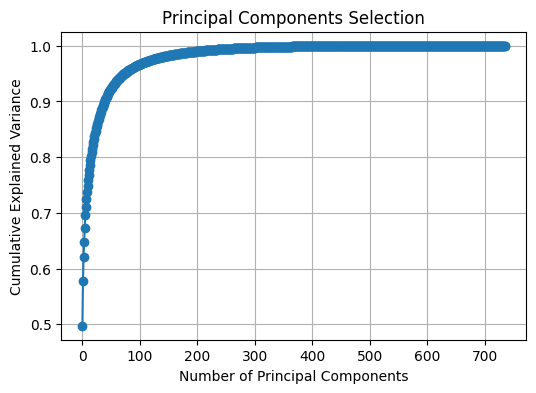

In [47]:
# Cumulative variance plot
cumulative_variance = np.cumsum(eigenvalues_sorted) / np.sum(eigenvalues_sorted)

plt.figure(figsize=(6,4))
plt.plot(cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Principal Components Selection')
plt.grid(True)
plt.show()

In [48]:
# Choose top k eigenvectors that explain > 95% variance
k = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of principal components to retain 95% variance: {k}")
top_k_eigenvectors = eigenvectors_sorted[:, :k]

Number of principal components to retain 95% variance: 74


3. Reconstruction and Experiment:

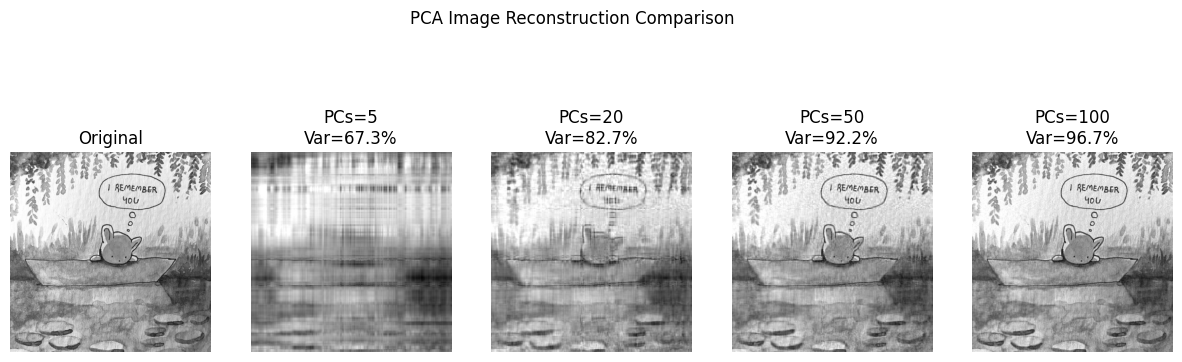

In [54]:
# Function to reconstruct using top k components
def reconstruct_image(data_std, mean, eigenvectors, k):
    top_k_eigvecs = eigenvectors[:, :k]         # select top k eigenvectors
    lower_dim = np.dot(data_std, top_k_eigvecs) # project to lower dimension
    reconstruction = np.dot(lower_dim, top_k_eigvecs.T) + mean
    return reconstruction

# Experiments: Pick 4 different k values
k_values = [5, 20, 50, 100]  # Number of principal components
plt.figure(figsize=(15, 5))

# Display original image
plt.subplot(1, len(k_values)+1, 1)
plt.imshow(img_array, cmap='gray')
plt.title("Original")
plt.axis('off')

# Display reconstructed images
for i, k in enumerate(k_values):
    reconstructed = reconstruct_image(standardized_data, mean, eigenvectors_sorted, k)
    reconstructed = np.clip(reconstructed, 0, 255)

    plt.subplot(1, len(k_values)+1, i+2)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"PCs={k}\nVar={cumulative_variance[k-1]*100:.1f}%")
    plt.axis('off')

plt.suptitle("PCA Image Reconstruction Comparison")
plt.show()